**NSL-KDD** is a data set containing rows of network connections. One row is one connection. It has 43 columns which capture data ranging from connection duration and protoocl type to error rates. Each row ( connection ) has a label which classifies the connection as normal or an attack, with different labels for different attacks.

In [105]:
import pandas as pd

In [106]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

In [107]:
df = pd.read_csv('data/KDDTrain+.txt',header=None,names=columns)

Organize labels ( attack names ) into 5 distinct categories defined in `attack_map` in order to have a more high level view on the dataset contents and attack groups.

- **Normal** – legitimate network traffic; not an attack.

- **DoS (Denial of Service)** – overwhelms a system or network with traffic or requests to make it unavailable.

- **Probe** – scans and reconnaissance activities used to discover hosts, services, ports, or vulnerabilities (e.g., Nmap scans, ping sweeps).

- **R2L (Remote to Local)** – an attacker without an account gains access to a target system from a remote location by exploiting vulnerabilities or weak credentials.

- **U2R (User to Root)** – an attacker who already has normal user access escalates privileges to gain root/administrator access by exploiting system vulnerabilities or misconfigurations.

In [108]:
attack_map = {
    'normal': 'Normal',
    'neptune': 'DoS', 'back': 'DoS', 'land': 'DoS', 'pod': 'DoS',
    'smurf': 'DoS', 'teardrop': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS',
    'processtable': 'DoS', 'mailbomb': 'DoS', 'worm': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'nmap': 'Probe',
    'portsweep': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L',
    'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L',
    'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L',
    'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    'buffer_overflow': 'U2R', 'loadmodule': 'U2R', 'rootkit': 'U2R',
    'perl': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R', 'ps': 'U2R'
}

In [109]:
df['attack_category'] = df['label'].map(attack_map)

In [110]:
df['attack_category'].value_counts()

attack_category
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

## Q1 - What does this dataset look like?

We must run basic operations to explore our data set structure, size and basic infromation.

- `df.shape` tells us we have 125973 rows and 44 columns 
- `df.head` returns first 5 rows along with columns
- `df.dtypes` returns each column along with information about its' data type
- `df.describe` returns list of basic statistic information. Output below tells us 
- `src_bytes` - bytes transfered over each connection ranges from 0 to 1.4GB. This means some connections might describe SYN floods which are connections that have no data, have just been opened with 0 bytes transfered.

With connections ranging from 0 bytes to 1.3gb we must normalize them in order to present them on a graph - results near 0 would get "eaten" by those high ones meaning anomalities would be hard to spot. Introducing log methods keeps the results highly widespread while reducing the differences between them.

In [111]:
df.shape

(125973, 44)

In [112]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,attack_category
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,Normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,Normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,DoS
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,Normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,Normal


In [113]:
df.dtypes

duration                         int64
protocol_type                      str
service                            str
flag                               str
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

In [114]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [115]:
import numpy as np
print(np.log1p(0))
print(np.log1p(276))
print(np.log1p(1379964000))

0.0
5.6240175061873385
21.04532324954339


## Q2 - How balanced are the attack categories?

Normal connections make up 53% of all data, rest are attacks. U2R is just 52 connections, meaning 0.02% of the dataset. Accuracy is a misleading metric when classes are imbalanced. A model can score 53% accuracy while being completely blind to the attacks we actually care about, only detecting the 53% normal traffic.

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
counts = df['attack_category'].value_counts()
total = counts.sum()

In [118]:
(counts / total) * 100

attack_category
Normal    53.458281
DoS       36.457812
Probe      9.252776
R2L        0.789852
U2R        0.041279
Name: count, dtype: float64

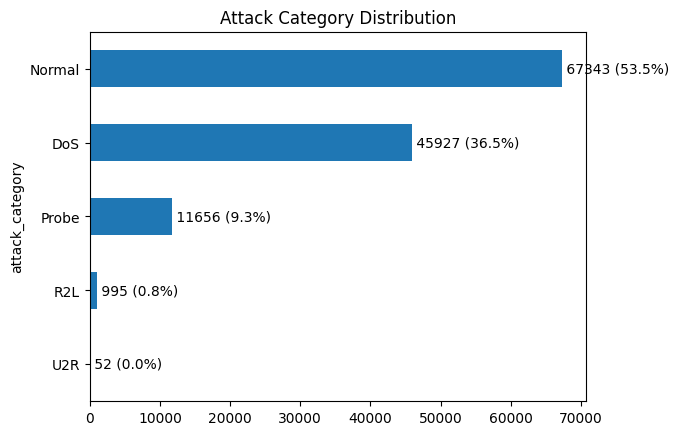

In [119]:
plt.title('Attack Category Distribution')
plt.xlabel('Count')
counts.sort_values().plot(kind='barh');
for i, (count, pct) in enumerate(zip(counts.sort_values(), counts.sort_values() / total * 100)):
    plt.text(count, i, f' {count} ({pct:.1f}%)', va='center')

## Q3 - Which specific attack types exist and how many of each?

DoS attacks make up the majority of malicious connections with having a score of 78.3%. Second most common are Probe attacks with 19.9% and least common are R2L with 1.7% and fianlly U2r attacks with just 0.1% of all attacks.

The most common attack by far is `Neptune` with a staggering  32.7% of all connections in the system and 70% of all attacks.

In [120]:
attack_counts = df[df['label'] != 'normal']['label'].value_counts()

print(41214 / attack_counts.sum() * 100 )

70.29507078287565


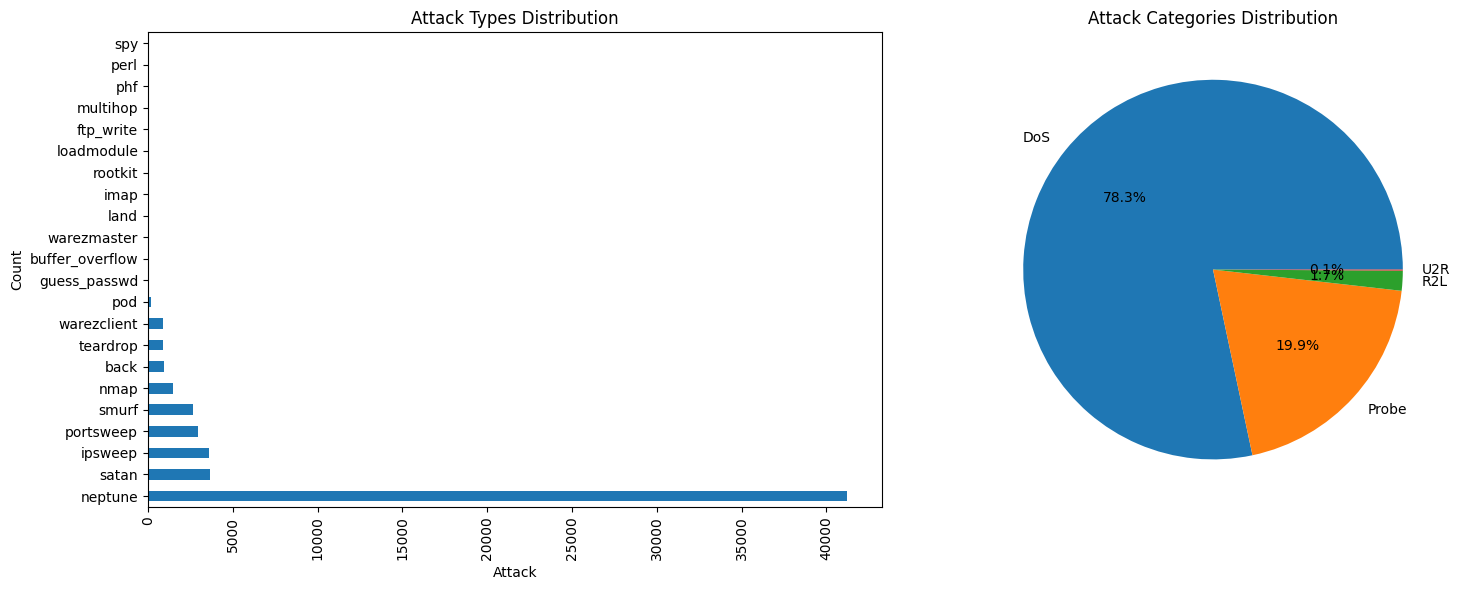

In [121]:
# Attack names
attack_counts = df[df['label'] != 'normal']['label'].value_counts()

# Attack categories
category_counts = df[df['attack_category'] != 'Normal']['attack_category'].value_counts()

plt.figure(figsize=(16, 6))

# Bar chart - individual attacks
plt.subplot(1, 2, 1)
attack_counts.plot(kind='barh')
plt.title('Attack Types Distribution')
plt.xlabel('Attack')
plt.ylabel('Count')
plt.xticks(rotation=90)

# Pie chart - attack categories
plt.subplot(1, 2, 2)
category_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Attack Categories Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

## Q4 - What types of features does this dataset have?

The dataset has been split into 3 feature types:
- categorical
- binary
- numerical

This dataset will be used for a ML model which needs constant numerical input, having data that is not an numerical is will break the model. Categorical features `protocol type`, `service`, `flag` need to be encoded. Continuous numerical features may need scaling — because of the extreme value ranges we saw in Q1

In [122]:

categorical = (
    df.select_dtypes(include=['object', 'string'])
      .columns
      .drop(['label', 'attack_category'])
      .tolist()
)
binary = [col for col in df.columns if df[col].nunique() == 2]
numerical = sorted(set(df.columns) - set(categorical) - set(binary) - {'difficulty'})

print(f"Categorical ({len(categorical)}): {categorical}")
print(f"Binary ({len(binary)}): {binary}")
print(f"Numerical ({len(numerical)}): {numerical[:5]}...")

Categorical (3): ['protocol_type', 'service', 'flag']
Binary (5): ['land', 'logged_in', 'root_shell', 'is_host_login', 'is_guest_login']
Numerical (35): ['attack_category', 'count', 'diff_srv_rate', 'dst_bytes', 'dst_host_count']...


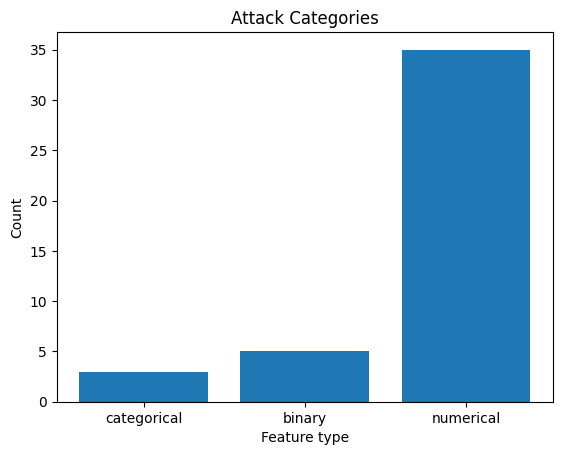

In [123]:
categories = ['categorical', 'binary', 'numerical']
counts = [len(categorical), len(binary), len(numerical)]

plt.bar(categories, counts)

plt.xlabel('Feature type')
plt.ylabel('Count')
plt.title('Attack Categories')

plt.show()

## Q5 - Are there any missing values?

Missing values might occur when data is lost, IOT sensors are broken or for any other reason. Missing values crash most ML models, any information that is corrupted and fed to an ML will have yield a malformed output. In our dataset we've found no missing values, this is highly unlikely for a real world scenario, this data set has been cleaned beforehand.

In [124]:
df.isnull().sum().sum()

np.int64(0)

## Q6 - How do key traffic features differ between normal and attack traffic?

We've chosen 3 main traffic features:

- **src_bytes** - bytes sent from client to host
- **dst_bytes** - bytes sent from host to client
- **duration** - duration of the connection

DoS connections have a very low byte count and duration count, this proves a SYN flood might have been executed ( many requests, empty, never responding to server and keeping it waiting ), although some DoS connections show to have anomalities pointing towards a more classical ping DoS

Normal and U2R connection have similar values in byte sizes, U2R is a local attack that doesn't produce distinctive network patterns.Because similarity to normal data it will be hard to distinguish. R2L attacks have a high src byte count, while being more spread out in dst bytes.

Log transform has been applied in order to make the visualization more readable, grouping all values closer to each other. This is purely visual, since there was a substantial range of values in the dataset. Without this transformation, a few massive numbers would dominate the chart, flattening the smaller, more common values against the baseline and making them impossible to see.

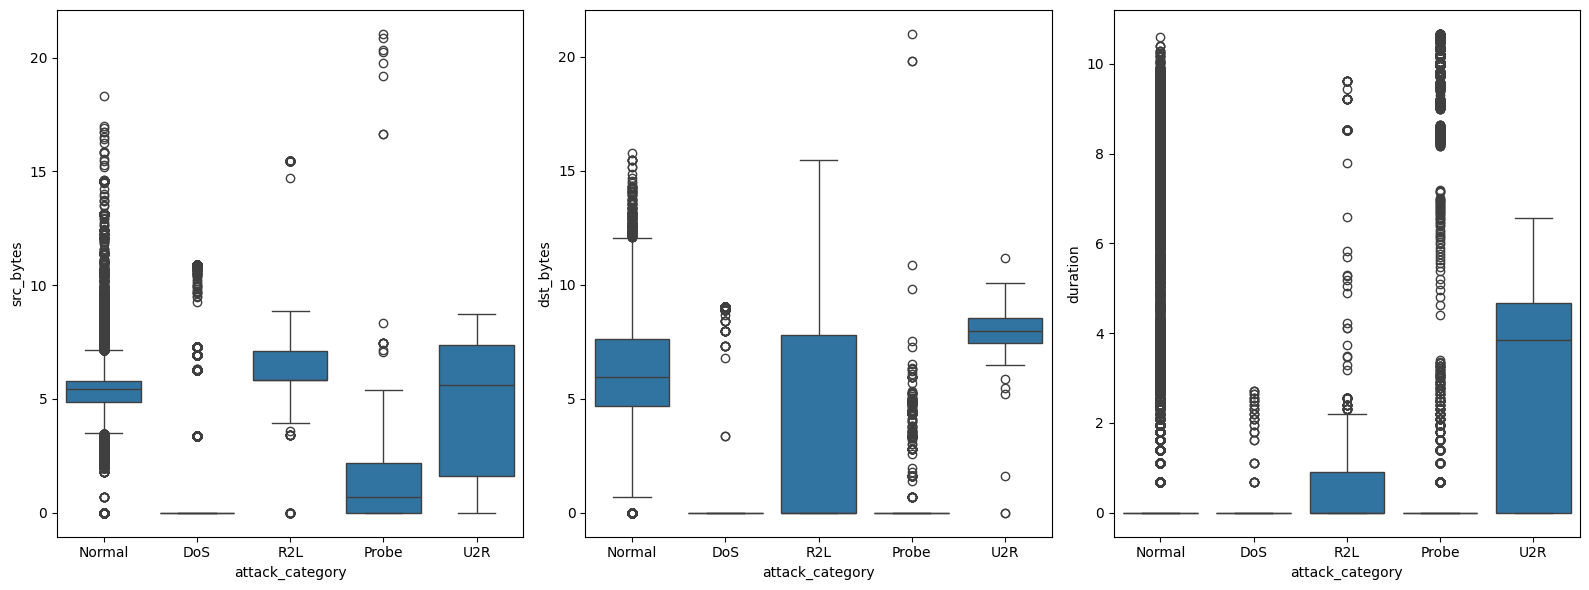

In [125]:
plt.figure(figsize=(16, 6))


plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='attack_category', y=np.log1p(df['src_bytes']));

plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='attack_category', y=np.log1p(df['dst_bytes']));

plt.subplot(1,3,3)
sns.boxplot(data=df, x='attack_category', y=np.log1p(df['duration']));

plt.tight_layout()
plt.show()

## Q7 - Which protocols are used and how do they relate to attacks?

Most attacks happen through TCP because it's a protocol using a stable connection ( also most common ). Probe attacks have smimilar distirbution on all 3 protocols since their main goal is "scanning" networks ( for example for open ports ) so that protocol doesn't matter.
R2L is absent from udp, because it targets mostly ssh, imap and ftp.

<Axes: xlabel='protocol_type'>

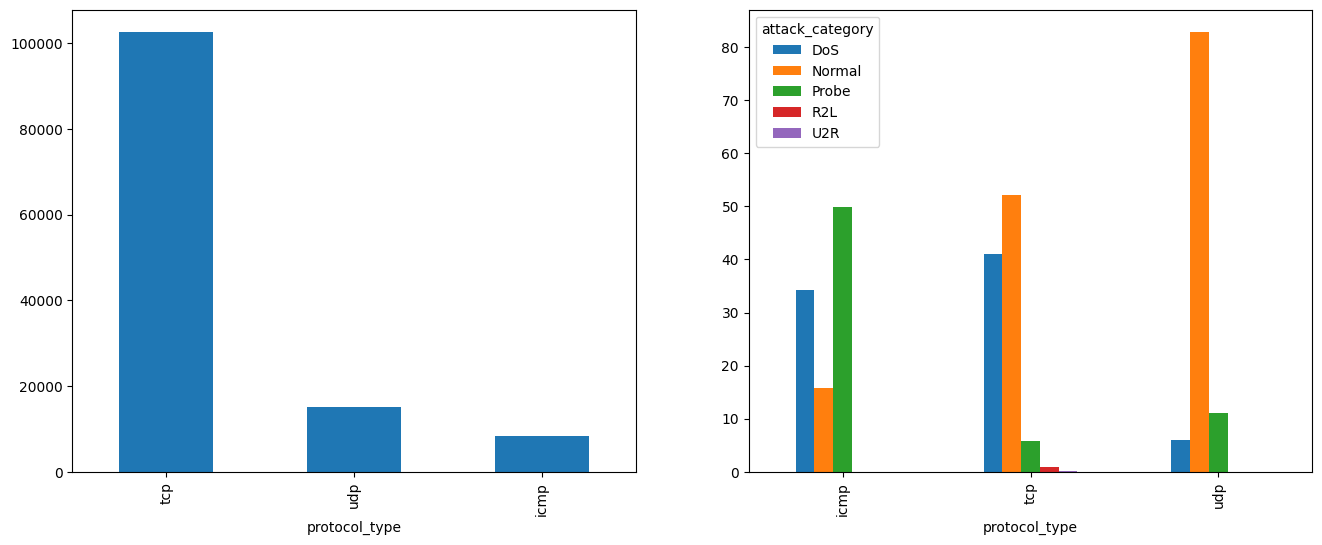

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 goes to axes[0]
counts = df['protocol_type'].value_counts()
counts.plot(kind='bar', ax=axes[0])

# Plot 2 goes to axes[1]
types = pd.crosstab(df['protocol_type'], df['attack_category'], normalize='index') * 100
types.plot(kind='bar', ax=axes[1])

## Q8 - Which services are most targeted in attacks?

In all connections - as expected HTTP dominates because of web traffic. Looking at attack services only we can see private is the most used service. Those are  connections to high-numbered ports with no well-known service. Port scanners hit these to find what's running on non-standard ports. Following that, for attacks most used are co_i / ecr_i — ICMP echo request and echo reply. Basically ping traffic. Used in ping sweeps (probe) and smurf attacks (DoS).


So the attack chart being dominated by private, eco_i, ecr_i actually confirms what we found in Q7 — probe attacks spread across all protocols, and ICMP is heavily used for scanning.

<Axes: title={'center': 'Top 20 service ( during attacks ) occurances'}, xlabel='service'>

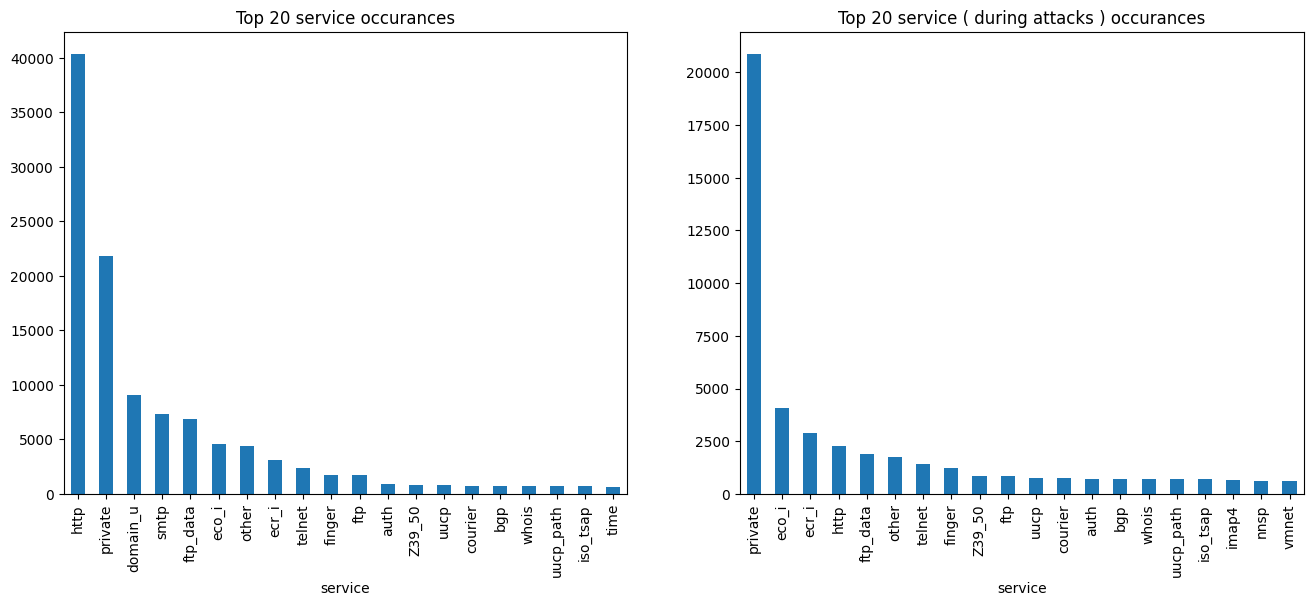

In [127]:
plt.figure(figsize=(16, 6));


plt.subplot(1, 2, 1)
plt.title('Top 20 service occurances')
service_counts = df['service'].value_counts().head(20)
service_counts.plot(kind='bar')

plt.subplot(1, 2, 2)
plt.title('Top 20 service ( during attacks ) occurances')
service_attack_counts = df[df['label'] != 'normal']['service'].value_counts().head(20)
service_attack_counts.plot(kind='bar')

## Q9 - How correlated are the numerical features?

Two correlated features carry almost identical information, if one goes up, the other one does too. If my age changes by 1, so does the age of my parents. Having both strongly correlated features in a model is redundant since they produce very similar ( if not identical ) output.

This data set has many correlated features, main correlation is `num_root` <-> `num_compromised` meaning each time an attacker accessed the system as root a new compromise has been detected. Apart from this, mostly erorrs show correlation, one error can trigger another error, or errors can be similar, measured in slightly different ways, resulting in correlation.

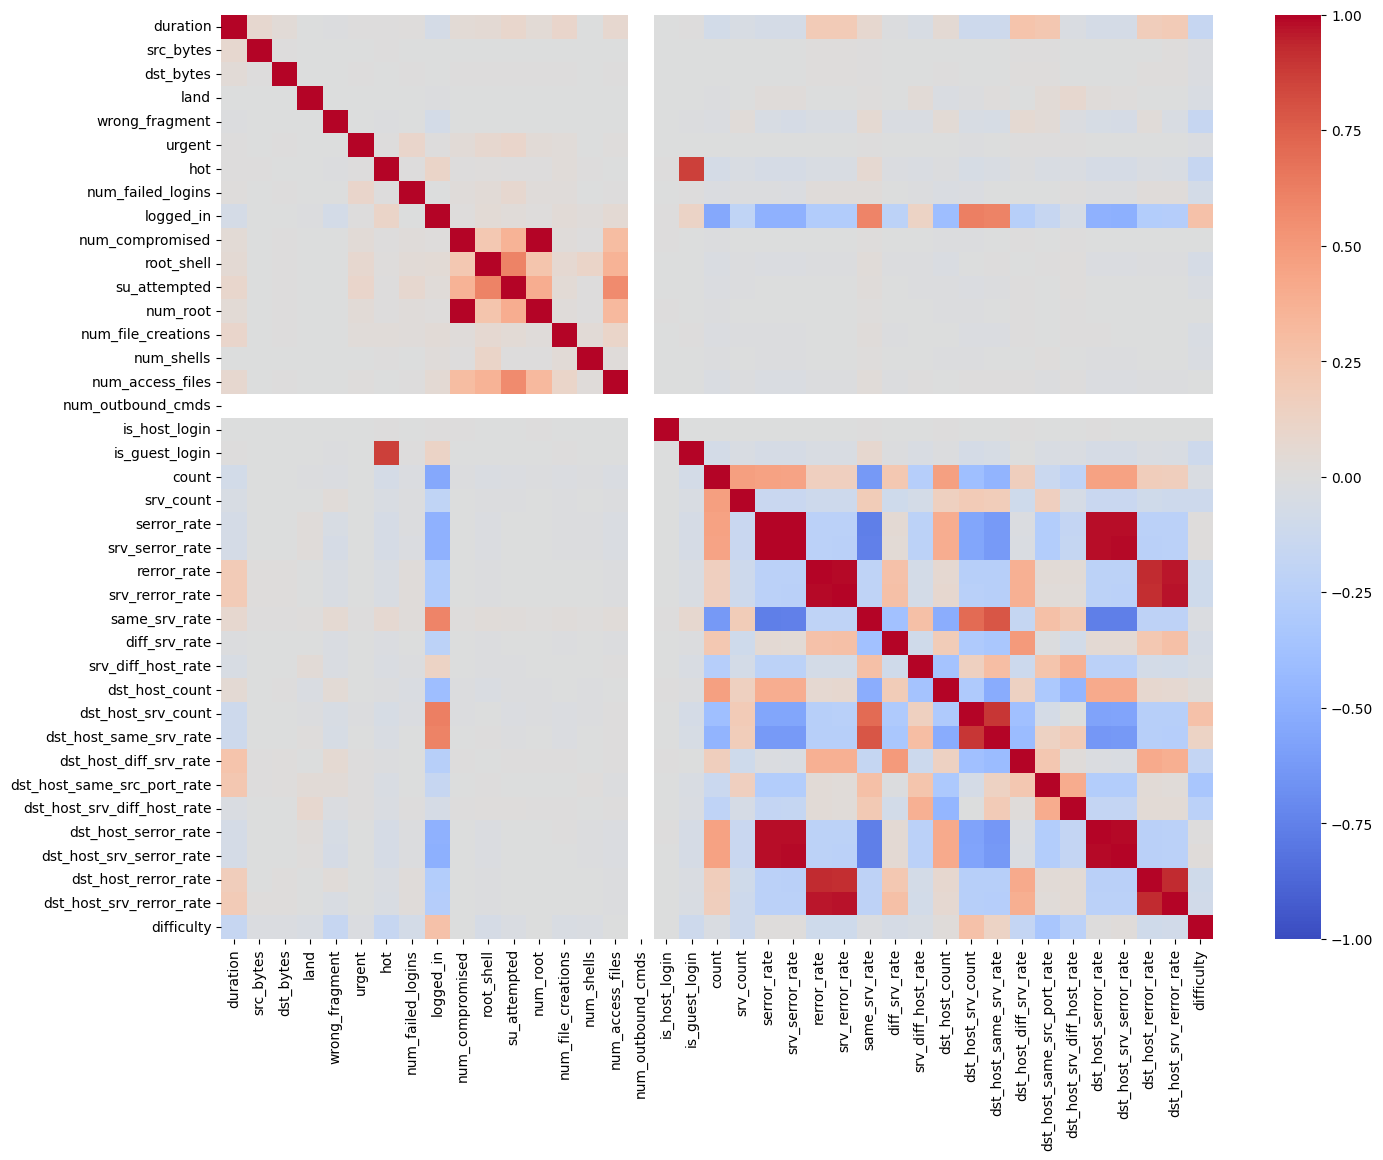

In [128]:
df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(16, 12))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [129]:
corr_matrix = df.select_dtypes(include=['number']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corr = upper.stack().sort_values(ascending=False).head(10)
print(top_corr)

num_compromised       num_root                    0.998833
serror_rate           srv_serror_rate             0.993289
rerror_rate           srv_rerror_rate             0.989008
srv_serror_rate       dst_host_srv_serror_rate    0.986252
dst_host_serror_rate  dst_host_srv_serror_rate    0.985052
serror_rate           dst_host_srv_serror_rate    0.981139
                      dst_host_serror_rate        0.979373
srv_serror_rate       dst_host_serror_rate        0.977596
srv_rerror_rate       dst_host_srv_rerror_rate    0.970208
rerror_rate           dst_host_srv_rerror_rate    0.964449
dtype: float64


## Q10 - What is the statistical "fingerprint" of each attack category?

In order to have a clear overview of attacks and their key features we've done min-max normalizatoin on the key data.

* **DoS** - lowest duration and amount of bytes ( mainly SYN flooding ) with highest count - meaning rapid repeated connections - typical for DoS, serror_rate and srv_count - meaning highly repeatable attack across services.
* **Normal** - connections with second highest srv_count - meaning span a variety of services, similar metrics to U2R with only srv_count having a stark difference making them hard to differentiate, this is partly because U2R is not common in networking and doesn't havea distinct pattern.
* **Probe** - visibly longest attack duration, amount of bytes and rejection error rates - normal behavoiur for port sniffing / scanning. Low SYN error rate, which makes sense - does not focus on handshakes.
* **R2L** - second to most high duration, happens mostly because it uses ftp / ssh which need an open control connection ( having data connection on top ), the high byte numbers are explained by ftp / ssh mainly being used to transfer data and perform brute operations  within attacks which havea high byte cost, tthe 10% rejection error makes sense since those attacks focus on penetration testing.

In [130]:
key_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'serror_rate', 'rerror_rate']
profile = df.groupby('attack_category')[key_features].mean()
print(profile)

                    duration      src_bytes      dst_bytes       count  \
attack_category                                                          
DoS                 0.006227    1176.321162     169.201537  178.090034   
Normal            168.587396   13133.279331    4329.685223   22.517945   
Probe            2074.858185  385679.838367  181074.911805   77.052248   
R2L               633.417085  307727.300503   81822.026131    1.297487   
U2R                80.942308     906.230769    5141.961538    5.807692   

                 srv_count  serror_rate  rerror_rate  
attack_category                                       
DoS              32.656346     0.748494     0.152107  
Normal           27.685654     0.013441     0.044196  
Probe            10.936084     0.046525     0.437319  
R2L               2.457286     0.011899     0.051759  
U2R               1.269231     0.038077     0.009808  


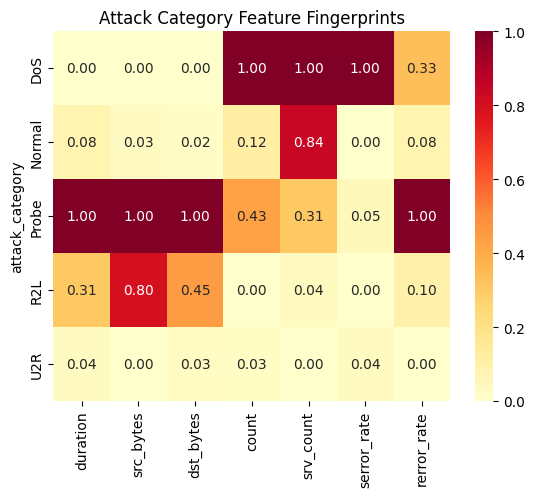

In [131]:
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())
sns.heatmap(profile_norm, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Attack Category Feature Fingerprints')
plt.show()

## Main takeaways:

* **1:** Dataset is highly imbalanced with different attacks towering in numbers over other attacks, normalization is required so both extreme sides of the data - lowest and highest are readable.

* **2:** This dataset is big, but it does not represent real life attack data sets, with logs only focusing on network connections, out of the box categorized and most importantly with 0 missing values - the dataset requires some segmentation and categorizing but it is exponentially cleaner than any real world scenario data.

* **3:** The dataset is overwhelmed by DoS connections, which makes sense because it is by far the most common attack pattern in network attacks. DoS attack highly correlate with syn errors pointing at SYN floods ( neptune )

* **4:** We cannot "trust" all the data in this set, especially U2R since there is not enough data, furthermore U2R are rarely network attacks, since user is alraedy in the network. The data for U2R is highly similar to normal data because U2R does not have a distinct network pattern.

* **5:** Data is highly correlated across the dataset, TCP is most common protocol while DoS is the most common attack, private is the most targetet service since there is a lot of probe attacks spanning different services and sniffing different ports. All data across dataset is logical without unusual anomalities. many features in this dataset measure similar things from slightly different angles (like serror_rate and srv_serror_rate), making them redundant for ML.